In [301]:
import gpxpy
import gpxpy.gpx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from folium.vector_layers import Rectangle
from shapely.geometry import LineString
from shapely.ops import unary_union
from shapely.geometry import Point
import pandas as pd
from math import exp, sqrt, pi
import networkx as nx
from shapely.geometry import LineString, Point
from geopy.distance import geodesic, great_circle

Total nodes in graph: 4995
Total edges in graph: 5697
Route length: 9.35 km
Route coordinates (lon, lat): 346 points
Number of blue nodes inside 100m geofence: 383


/var/folders/q2/v14my5x946b7x25sxwf5z0nh0000gn/T/ipykernel_63972/776833555.py:89: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


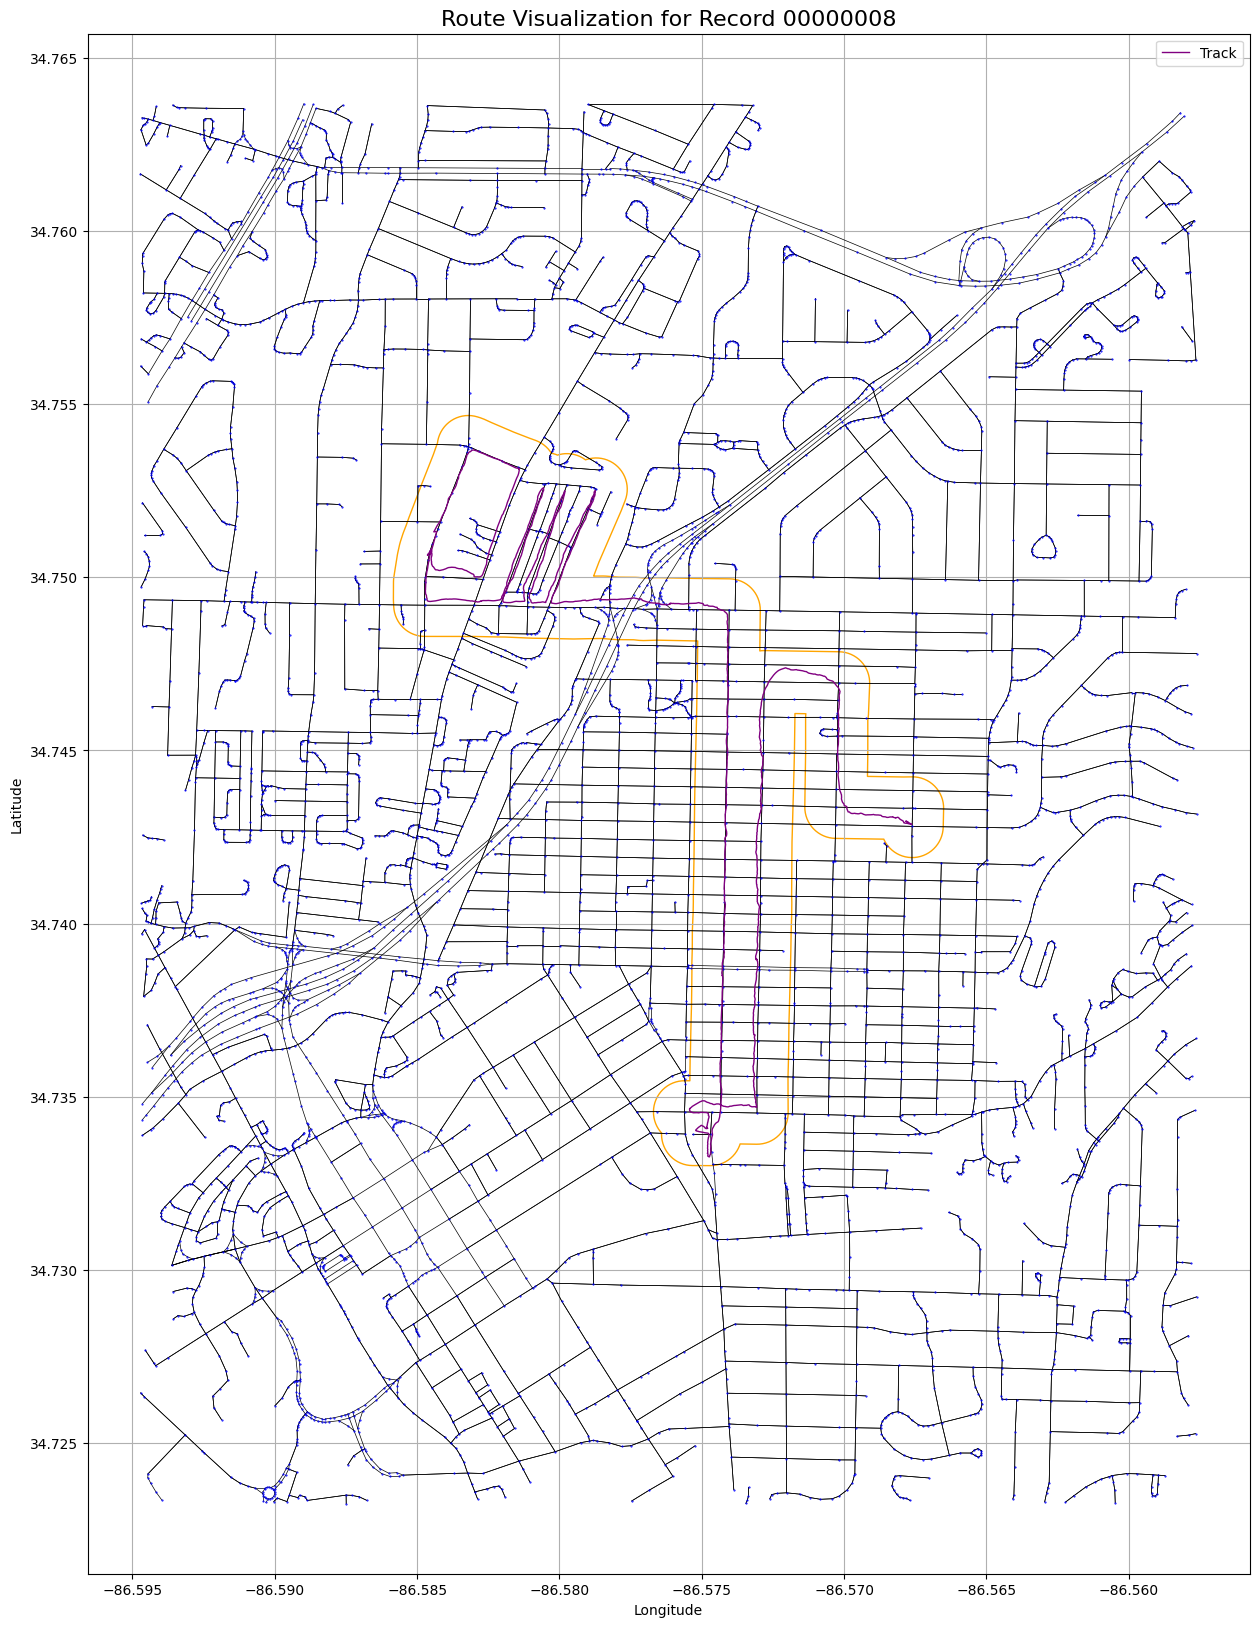

In [302]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString
from math import radians, sin, cos, sqrt, atan2

def haversine(coord1, coord2):
    lon1, lat1 = coord1
    lon2, lat2 = coord2
    R = 6371.0
    dlon = radians(lon2 - lon1)
    dlat = radians(lat2 - lat1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

id = 8
fn = f'./{id:08d}/{id:08d}'
track = np.loadtxt(f'{fn}.track', delimiter='\t')
route = np.loadtxt(f'{fn}.route', delimiter='\t')
nodes = np.loadtxt(f'{fn}.nodes', delimiter='\t')
arcs = np.loadtxt(f'{fn}.arcs', delimiter='\t')

G = nx.Graph()
for i, node in enumerate(nodes):
    G.add_node(i, coord=tuple(node[:2]))

for arc in arcs:
    src_idx = int(arc[0])
    dst_idx = int(arc[1])
    G.add_edge(src_idx, dst_idx)

print(f"Total nodes in graph: {G.number_of_nodes()}")
print(f"Total edges in graph: {G.number_of_edges()}")

plt.figure(figsize=(15, 20))
xmargin = (-min(nodes[:, 0]) + max(nodes[:, 0])) / 20
ymargin = (-min(nodes[:, 1]) + max(nodes[:, 1])) / 20
plt.axis([
    min(nodes[:, 0]) - xmargin, max(nodes[:, 0]) + xmargin,
    min(nodes[:, 1]) - ymargin, max(nodes[:, 1]) + ymargin
])

for i in range(arcs.shape[0]):
    arc = np.array([nodes[int(arcs[i, 0]), :2], nodes[int(arcs[i, 1]), :2]])
    plt.plot(arc[:, 0], arc[:, 1], 'k', linewidth=0.5)

plt.plot(nodes[:, 0], nodes[:, 1], 'o', markersize=0.5, color='blue')

route_coords_list = []
route_length_km = 0
for i in range(route.shape[0]):
    arc_idx = int(route[i])
    src_idx = int(arcs[arc_idx, 0])
    dst_idx = int(arcs[arc_idx, 1])
    src = nodes[src_idx, :2]
    dst = nodes[dst_idx, :2]
    route_coords_list.append(src)
    route_coords_list.append(dst)
    route_length_km += haversine(src, dst)

print(f"Route length: {route_length_km:.2f} km")
print("Route coordinates (lon, lat):", len(route_coords_list), "points")

route_coords = np.array(route_coords_list)

route_line = LineString(route_coords)
gdf_route = gpd.GeoSeries([route_line], crs='EPSG:4326')
centroid = gdf_route.geometry.union_all().centroid
utm_zone = int((centroid.x + 180) / 6) + 1
epsg_utm = 32600 + utm_zone

gdf_route_utm = gdf_route.to_crs(epsg=epsg_utm)
geofence_polygon = gdf_route_utm.buffer(100).geometry.union_all()
geofence_latlon = gpd.GeoSeries([geofence_polygon], crs=f"EPSG:{epsg_utm}").to_crs(epsg=4326)
geofence_latlon.plot(ax=plt.gca(), facecolor='none', edgecolor='orange', linewidth=1, label='100m Geofence')

gdf_nodes = gpd.GeoDataFrame(geometry=gpd.points_from_xy(nodes[:,0], nodes[:,1]), crs='EPSG:4326')
gdf_nodes_utm = gdf_nodes.to_crs(epsg=epsg_utm)

nodes_in_geofence_mask = gdf_nodes_utm.within(geofence_polygon)
nodes_in_geofence = nodes[nodes_in_geofence_mask.values]

print(f"Number of blue nodes inside 100m geofence: {len(nodes_in_geofence)}")

plt.plot(track[:, 0], track[:, 1], color='purple', linewidth=1, label='Track')

plt.legend()
plt.title(f"Route Visualization for Record {id:08d}", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


In [303]:
import numpy as np
from geopy.distance import geodesic

observations = None  

def closest_nodes_to_track(id):
    global observations
    fn = f'./{id:08d}/{id:08d}'
    observations = np.loadtxt(f'{fn}.track', delimiter='\t')   
    nodes = np.loadtxt(f'{fn}.nodes', delimiter='\t')

    closest_nodes = []
    distances = []

    for t in observations:
        t_coord = (t[1], t[0])
        min_dist = float("inf")
        closest_node = None
        for n in nodes:
            n_coord = (n[1], n[0])
            d = geodesic(t_coord, n_coord).meters
            if d < min_dist:
                min_dist = d
                closest_node = n
        closest_nodes.append(closest_node)
        distances.append(min_dist)

    return closest_nodes, distances

closest_nodes, distances = closest_nodes_to_track(50)

print("Closest nodes to each track point:", closest_nodes)
print("Distances (meters):", distances)


Closest nodes to each track point: [array([ 8.773965, 48.016348]), array([ 8.773551, 48.016618]), array([ 8.773551, 48.016618]), array([ 8.773344, 48.016789]), array([ 8.773149, 48.016926]), array([ 8.773149, 48.016926]), array([ 8.772913, 48.017184]), array([ 8.772913, 48.017184]), array([ 8.772723, 48.017444]), array([ 8.772723, 48.017444]), array([ 8.772561, 48.017759]), array([ 8.772561, 48.017759]), array([ 8.772328, 48.017953]), array([ 8.772328, 48.017953]), array([ 8.77241 , 48.018228]), array([ 8.772226, 48.018447]), array([ 8.772226, 48.018447]), array([ 8.772339, 48.018702]), array([ 8.772175, 48.018783]), array([ 8.772302, 48.019201]), array([ 8.772302, 48.019201]), array([ 8.772302, 48.019201]), array([ 8.772194, 48.019657]), array([ 8.772194, 48.019657]), array([ 8.772199, 48.020009]), array([ 8.772316, 48.020089]), array([ 8.772316, 48.020089]), array([ 8.772231, 48.020453]), array([ 8.772231, 48.020453]), array([ 8.772548, 48.020595]), array([ 8.772418, 48.020843]), arr

In [304]:
print(track.shape)
print(track[:5])


(3093, 3)
[[-86.567832  34.74296    1.      ]
 [-86.567832  34.742962   2.      ]
 [-86.567829  34.742961   3.      ]
 [-86.567827  34.742958   4.      ]
 [-86.567814  34.742953   5.      ]]


Sigma emission: 29.769947815290667
Beta: 2.993997533250386
Matched node indices (len=3093):
[2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356, 2356]
Matched coordinates (first 10):
[(np.float64(-86.567611), np.float64(34.74281)), (np.float64(-86.567611), np.float64(34.74281)), (np.float64(-86.567611), np.float64(34.74281)), (np.float64(-86.567611), np.float64(34.74281)), (np.float64(-86.567611), np.float64(34.74281)), (np.float64(-86.567611), np.float64(34.74281)), (np.float64(-86.567611), np.float64(34.74281)), (np.float64(-86.567611), np.float64(34.74281)), (np.float64(-86.567611), np.float64(34.74281)), (np.float64(-86.567611), np.float64(34.74281))]


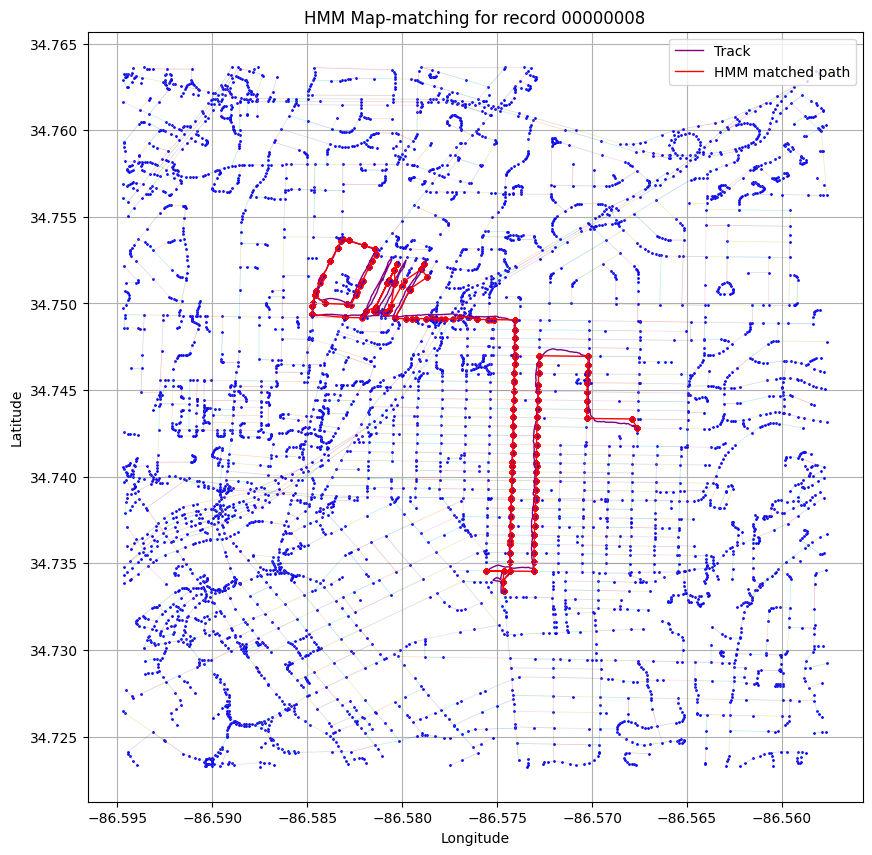

In [305]:
import numpy as np
import networkx as nx
from geopy.distance import geodesic
from shapely.geometry import LineString
import matplotlib.pyplot as plt
import math

id = 8
fn = f'./{id:08d}/{id:08d}'
track = np.loadtxt(f'{fn}.track', delimiter='\t')
nodes = np.loadtxt(f'{fn}.nodes', delimiter='\t')
arcs = np.loadtxt(f'{fn}.arcs', delimiter='\t')

G = nx.Graph()
for i, node in enumerate(nodes):
    G.add_node(i, coord=(node[0], node[1]))
for arc in arcs:
    u = int(arc[0]); v = int(arc[1])
    p1 = (nodes[u,0], nodes[u,1]); p2 = (nodes[v,0], nodes[v,1])
    d = geodesic((p1[1], p1[0]), (p2[1], p2[0])).meters
    G.add_edge(u, v, weight=d)

observations = track[:, :2]

def generate_candidates(obs, nodes, K=5, max_radius=200):
    cand_idx = []; cand_dists = []
    for t in obs:
        t_coord = (t[1], t[0])
        dists = [geodesic((n[1], n[0]), t_coord).meters for n in nodes]
        idx_sorted = np.argsort(dists)
        selected = []; selected_dists = []
        for idx in idx_sorted[:K]:
            if dists[idx] <= max_radius or len(selected) < 1:
                selected.append(int(idx)); selected_dists.append(dists[idx])
        cand_idx.append(selected); cand_dists.append(selected_dists)
    return cand_idx, cand_dists

candidates_idx, candidates_dists = generate_candidates(observations, nodes, K=6, max_radius=200)
all_d = [d for sub in candidates_dists for d in sub]
sigma_emission = np.std(all_d) if np.std(all_d)>1e-6 else 50.0

obs_dists = [geodesic((observations[i-1,1], observations[i-1,0]), (observations[i,1], observations[i,0])).meters for i in range(1,len(observations))]
beta = np.mean(obs_dists) if len(obs_dists)>0 else 1000.0

def emission_logprob(dist_m):
    return -0.5 * (dist_m**2) / (sigma_emission**2) - math.log(sigma_emission * (2*math.pi)**0.5)

def transition_logprob(i, j):
    try:
        path_len = nx.shortest_path_length(G, source=i, target=j, weight='weight')
    except:
        return -1e9
    return -path_len / beta

T = len(observations)
cand_lists = candidates_idx
cand_dists_lists = candidates_dists

viterbi = []; backpointer = []
first_cands = cand_lists[0]; dp = {}
for k_idx, node_idx in enumerate(first_cands):
    d = cand_dists_lists[0][k_idx]
    dp[node_idx] = emission_logprob(d)
viterbi.append(dp)

for t in range(1, T):
    dp_next = {}; back_next = {}
    for j_pos, j in enumerate(cand_lists[t]):
        e_log = emission_logprob(cand_dists_lists[t][j_pos])
        best_score = -1e18; best_prev = None
        for i, score_i in viterbi[-1].items():
            trans = transition_logprob(i, j)
            s = score_i + trans + e_log
            if s > best_score:
                best_score = s; best_prev = i
        dp_next[j] = best_score; back_next[j] = best_prev
    viterbi.append(dp_next); backpointer.append(back_next)

last_dp = viterbi[-1]
best_last = max(last_dp, key=last_dp.get)
path_nodes = [best_last]
for t in range(T-1, 0, -1):
    bp = backpointer[t-1]; prev = bp[path_nodes[-1]]
    if prev is None:
        prev = max(viterbi[t-1].items(), key=lambda x:x[1])[0]
    path_nodes.append(prev)
path_nodes = list(reversed(path_nodes))

matched_coords = [(nodes[i,0], nodes[i,1]) for i in path_nodes]

print("Sigma emission:", sigma_emission)
print("Beta:", beta)
print("Matched node indices (len={}):".format(len(path_nodes)))
print(path_nodes[:20])
print("Matched coordinates (first 10):")
print(matched_coords[:10])

xs = nodes[:,0]; ys = nodes[:,1]
plt.figure(figsize=(10,10))
plt.plot(xs, ys, 'o', markersize=1, color='blue')
for e in G.edges():
    a = G.nodes[e[0]]['coord']; b = G.nodes[e[1]]['coord']
    plt.plot([a[0], b[0]], [a[1], b[1]], linewidth=0.5, alpha=0.3)
obs_x = observations[:,0]; obs_y = observations[:,1]
plt.plot(obs_x, obs_y, color='purple', linewidth=1, label='Track')
matched_x = [c[0] for c in matched_coords]; matched_y = [c[1] for c in matched_coords]
plt.plot(matched_x, matched_y, '-r', linewidth=1, label='HMM matched path')
plt.scatter(matched_x, matched_y, c='red', s=10)
plt.legend(); plt.title(f"HMM Map-matching for record {id:08d}")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(True)
plt.show()

In [ ]:
from geopy.distance import geodesic
import math

def bearing(coord1, coord2):
    lon1, lat1 = coord1
    lon2, lat2 = coord2
    dlon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    x = math.sin(dlon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    brng = math.degrees(math.atan2(x, y))
    return (brng + 360) % 360

def angle_diff(a, b):
    d = abs(a - b) % 360
    return d if d <= 180 else 360 - d

def reassign_nodes(observations, path_nodes, candidates_idx, nodes, G, angle_thresh=5, dist_thresh=30):
    reassigned = []
    logs = []
    for i in range(len(path_nodes)):
        if i == 0:
            reassigned.append(path_nodes[i])
            continue
        obs_angle = bearing(observations[i-1], observations[i])
        matched1 = nodes[path_nodes[i-1]]
        matched2 = nodes[path_nodes[i]]
        matched_angle = bearing((matched1[0], matched1[1]), (matched2[0], matched2[1]))
        try:
            path_len = nx.shortest_path_length(G, source=path_nodes[i-1], target=path_nodes[i], weight="weight")
        except:
            path_len = float("inf")
        angle_diff_val = angle_diff(obs_angle, matched_angle)
        if path_len > dist_thresh or angle_diff_val > angle_thresh:
            obs_coord = (observations[i][1], observations[i][0])
            best_node = path_nodes[i]
            best_angle = float("inf")
            best_dist = float("inf")
            for cand in candidates_idx[i]:
                cand_coord = (nodes[cand,0], nodes[cand,1])
                cand_angle = bearing((nodes[path_nodes[i-1],0], nodes[path_nodes[i-1],1]), cand_coord)
                cand_angle_diff = angle_diff(obs_angle, cand_angle)
                dist_to_obs = geodesic((cand_coord[1], cand_coord[0]), obs_coord).meters
                if (cand_angle_diff < best_angle) or (cand_angle_diff == best_angle and dist_to_obs < best_dist):
                    best_angle = cand_angle_diff
                    best_dist = dist_to_obs
                    best_node = cand
            if best_node != path_nodes[i]:
                logs.append((i, path_nodes[i], best_node, angle_diff_val, path_len))
            reassigned.append(best_node)
        else:
            reassigned.append(path_nodes[i])
    return reassigned, logs
reassigned_nodes, reassignment_logs = reassign_nodes(observations, path_nodes, candidates_idx, nodes, G)

print("-- Reassignment Logs --")
for log in reassignment_logs:
    print(f"Obs {log[0]}: {log[1]} -> {log[2]} | angle_diff={log[3]:.2f}, path_len={log[4]:.2f}")


-- Reassignment Logs --
Obs 2: 2356 -> 3041 | angle_diff=112.08, path_len=0.00
Obs 3: 2356 -> 3041 | angle_diff=151.29, path_len=0.00
Obs 4: 2356 -> 3041 | angle_diff=115.08, path_len=0.00
Obs 5: 2356 -> 3041 | angle_diff=127.26, path_len=0.00
Obs 6: 2356 -> 1539 | angle_diff=90.00, path_len=0.00
Obs 7: 2356 -> 1539 | angle_diff=39.41, path_len=0.00
Obs 8: 2356 -> 3041 | angle_diff=180.00, path_len=0.00
Obs 9: 2356 -> 1539 | angle_diff=55.94, path_len=0.00
Obs 10: 2356 -> 2070 | angle_diff=76.32, path_len=0.00
Obs 11: 2356 -> 2070 | angle_diff=90.00, path_len=0.00
Obs 12: 2356 -> 3041 | angle_diff=131.00, path_len=0.00
Obs 13: 2356 -> 3041 | angle_diff=108.68, path_len=0.00
Obs 14: 2356 -> 3041 | angle_diff=102.85, path_len=0.00
Obs 15: 2356 -> 1539 | angle_diff=90.00, path_len=0.00
Obs 16: 2356 -> 3041 | angle_diff=140.59, path_len=0.00
Obs 17: 2356 -> 3041 | angle_diff=131.00, path_len=0.00
Obs 18: 2356 -> 3041 | angle_diff=154.85, path_len=0.00
Obs 19: 2356 -> 3041 | angle_diff=140.

In [ ]:
import networkx as nx
from geopy.distance import geodesic
import math
from shapely.geometry import Point

pos = {i: (nodes[i,0], nodes[i,1]) for i in range(len(nodes))}

def geodesic_km(a, b):
    return geodesic((a[1], a[0]), (b[1], b[0])).km

def shortest_path_distance_subgraph(Gs, source, target):
    try:
        path = nx.shortest_path(Gs, source=source, target=target, weight=lambda u, v, d: geodesic_km(pos[u], pos[v]))
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return None, float('inf')
    dist = sum(geodesic_km(pos[path[i]], pos[path[i+1]]) for i in range(len(path)-1))
    return path, dist

def calculate_heading(p1, p2):
    lon1, lat1 = p1
    lon2, lat2 = p2
    lon1, lat1, lon2, lat2 = map(math.radians, (lon1, lat1, lon2, lat2))
    dlon = lon2 - lon1
    x = math.sin(dlon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def angle_diff_signed(a, b):
    diff = (b - a + 360) % 360
    return diff - 360 if diff > 180 else diff

angle_thresh = 5.0
dist_thresh_km = 0.1

nodes_in_geofence = [n for n in G.nodes if geofence.geometry[0].contains(Point(pos[n]))]
subgraph = G.subgraph(nodes_in_geofence).copy()


reassigned_nodes = [path_nodes[0]]
reassigned_log = []
reassignment_memory = {}

n_steps = min(len(path_nodes), len(observations))
for i in range(1, n_steps):
    fixed = reassigned_nodes[-1]
    orig_matched = path_nodes[i]
    obs_prev = observations[i-1]
    obs_curr = observations[i]

    obs_dist_km = geodesic((obs_prev[1], obs_prev[0]), (obs_curr[1], obs_curr[0])).km
    obs_heading = calculate_heading((obs_prev[0], obs_prev[1]), (obs_curr[0], obs_curr[1]))

    if fixed not in subgraph or orig_matched not in subgraph:
        matched_segment_km = float('inf')
    else:
        _, matched_segment_km = shortest_path_distance_subgraph(subgraph, fixed, orig_matched)

    if (fixed in pos) and (orig_matched in pos):
        matched_angle = calculate_heading(pos[fixed], pos[orig_matched])
        angle_diff_val = abs(angle_diff_signed(obs_heading, matched_angle))
    else:
        matched_angle = None
        angle_diff_val = 180.0

    trigger = (matched_segment_km > dist_thresh_km) or (angle_diff_val > angle_thresh)
    if not trigger:
        reassigned_nodes.append(orig_matched)
        continue

    candidates = []
    for cand in nodes_in_geofence:
        if cand == fixed:
            continue
        try:
            if not nx.has_path(subgraph, fixed, cand):
                continue
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            continue

        node_heading = calculate_heading(pos[fixed], pos[cand])
        ang_diff = abs(angle_diff_signed(obs_heading, node_heading))
        if ang_diff > angle_thresh:
            continue

        _, path_km = shortest_path_distance_subgraph(subgraph, fixed, cand)
        if not math.isfinite(path_km):
            continue

        dist_diff = abs(path_km - obs_dist_km)
        if dist_diff <= 0.07:
            candidates.append((ang_diff, dist_diff, cand))

    if candidates:
        candidates.sort(key=lambda x: (x[0], x[1]))
        best = candidates[0]
        reassigned_nodes.append(best[2])
        reassignment_memory[orig_matched] = best[2]
        reassigned_log.append((i, orig_matched, best[2], best[0], best[1], matched_segment_km, angle_diff_val))
        print(f"[REASSIGN] Obs {i}: matched {orig_matched} -> reassigned {best[2]} | ang_diff(orig)={angle_diff_val:.2f}° matched_seg_km={matched_segment_km:.4f} km | cand_ang={best[0]:.2f}°, cand_dist_diff={best[1]:.4f} km")
    else:
        reassigned_nodes.append(orig_matched)
        print(f"[KEEP] Obs {i}: kept matched {orig_matched} | ang_diff(orig)={angle_diff_val:.2f}° matched_seg_km={matched_segment_km:.4f} km")

print("-- Reassignment summary --")
print(f"Original matched count: {len(path_nodes)} reassigned count: {len(reassigned_nodes)}")


[KEEP] Obs 2: kept matched 2356 | ang_diff(orig)=112.08° matched_seg_km=0.0000 km
[KEEP] Obs 3: kept matched 2356 | ang_diff(orig)=151.29° matched_seg_km=0.0000 km
[KEEP] Obs 4: kept matched 2356 | ang_diff(orig)=115.08° matched_seg_km=0.0000 km
[KEEP] Obs 5: kept matched 2356 | ang_diff(orig)=127.26° matched_seg_km=0.0000 km
[KEEP] Obs 6: kept matched 2356 | ang_diff(orig)=90.00° matched_seg_km=0.0000 km
[KEEP] Obs 7: kept matched 2356 | ang_diff(orig)=39.41° matched_seg_km=0.0000 km
[REASSIGN] Obs 8: matched 2356 -> reassigned 3041 | ang_diff(orig)=180.00° matched_seg_km=0.0000 km | cand_ang=1.41°, cand_dist_diff=0.0296 km
[KEEP] Obs 9: kept matched 2356 | ang_diff(orig)=54.53° matched_seg_km=0.0297 km
[KEEP] Obs 10: kept matched 2356 | ang_diff(orig)=76.32° matched_seg_km=0.0000 km
[KEEP] Obs 11: kept matched 2356 | ang_diff(orig)=90.00° matched_seg_km=0.0000 km
[KEEP] Obs 12: kept matched 2356 | ang_diff(orig)=131.00° matched_seg_km=0.0000 km
[KEEP] Obs 13: kept matched 2356 | ang_

KeyboardInterrupt: 